# Section 1 – Imports

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/us-dollar-index-market-structure-dataset/Dx.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

plt.style.use("dark_background")

# Section 2 – Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/krupalpatel07/us-dollar-index-market-structure-dataset/Dx.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2000-06-22,107.099998,107.639999,106.900002,107.400002,666
2000-06-23,107.430000,107.879997,107.070000,107.720001,258
2000-06-26,107.680000,108.260002,107.599998,107.769997,266
2000-06-27,107.849998,107.849998,106.970001,106.980003,669
2000-06-28,107.059998,107.599998,107.029999,107.250000,258


# Section 3 – Feature Engineering

In [4]:
df["Return"] = df["Close"].pct_change()

df["Volatility"] = df["Return"].rolling(30).std() * np.sqrt(252)

df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

df["Year"] = df.index.year
df["Day"] = df.index.dayofyear

df.dropna(inplace=True)

# Visualization 1
## 3D Dollar Index Terrain Map

#### This converts price history into a terrain surface.

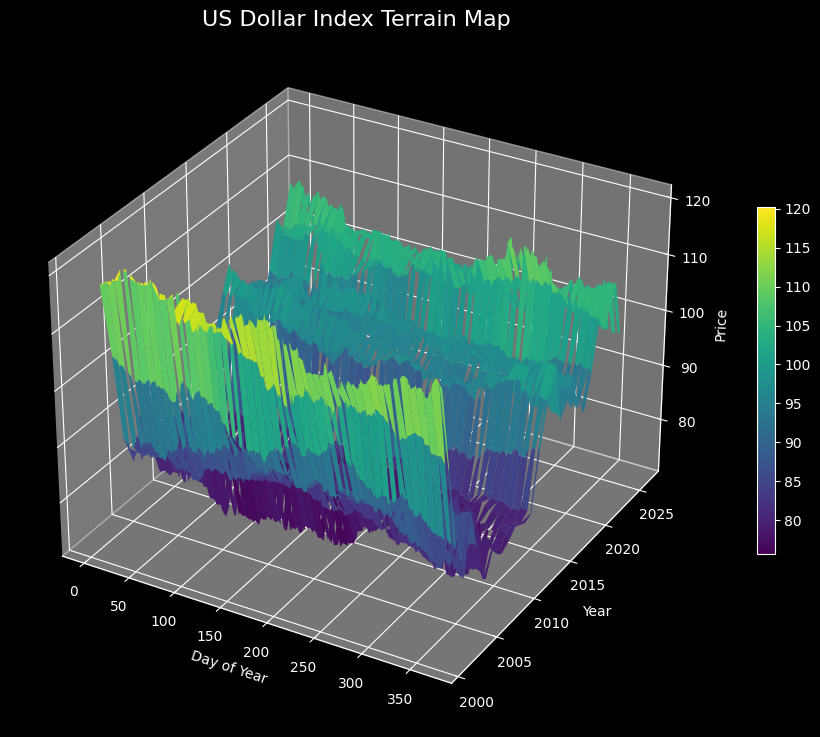

In [5]:
pivot = df.pivot_table(
    values="Close",
    index="Year",
    columns="Day",
    aggfunc="mean"
)

X = pivot.columns
Y = pivot.index

X, Y = np.meshgrid(X, Y)
Z = pivot.values

fig = plt.figure(figsize=(14,9))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_title("US Dollar Index Terrain Map", fontsize=16)

ax.set_xlabel("Day of Year")
ax.set_ylabel("Year")
ax.set_zlabel("Price")

fig.colorbar(surface, shrink=0.5)

plt.show()

# Visualization 2
## Volatility Galaxy Chart

#### This chart visualizes volatility clusters like a galaxy of stars.

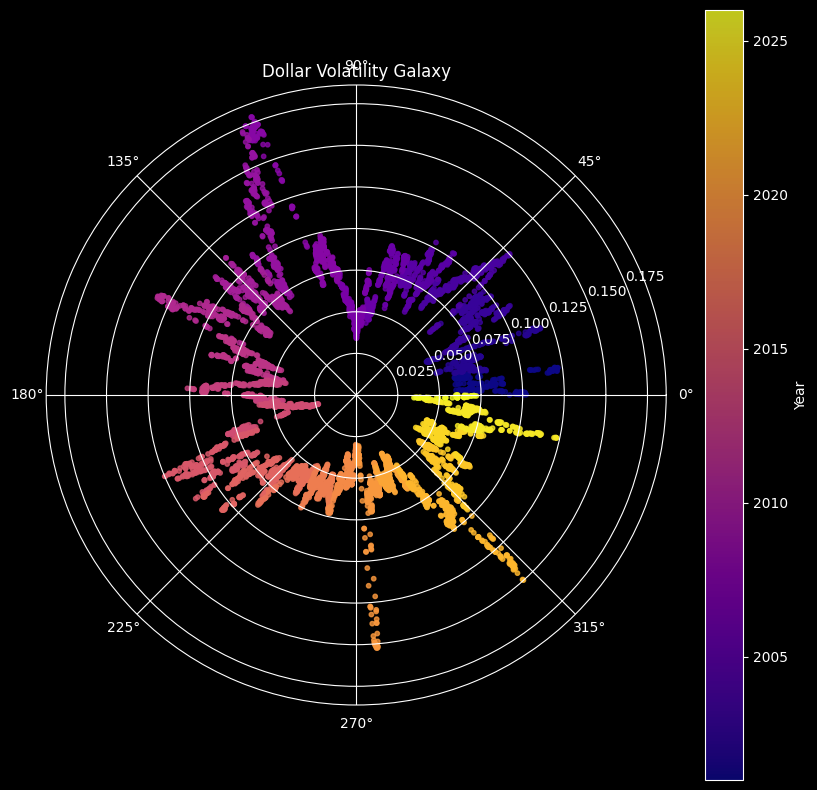

In [6]:
theta = np.linspace(0, 2*np.pi, len(df))

radius = df["Volatility"]

fig = plt.figure(figsize=(10,10))

ax = plt.subplot(projection="polar")

scatter = ax.scatter(
    theta,
    radius,
    c=df["Year"],
    cmap="plasma",
    s=10,
    alpha=0.8
)

plt.title("Dollar Volatility Galaxy")

plt.colorbar(scatter, label="Year")

plt.show()

# Visualization 3
## Macro Shock Detector

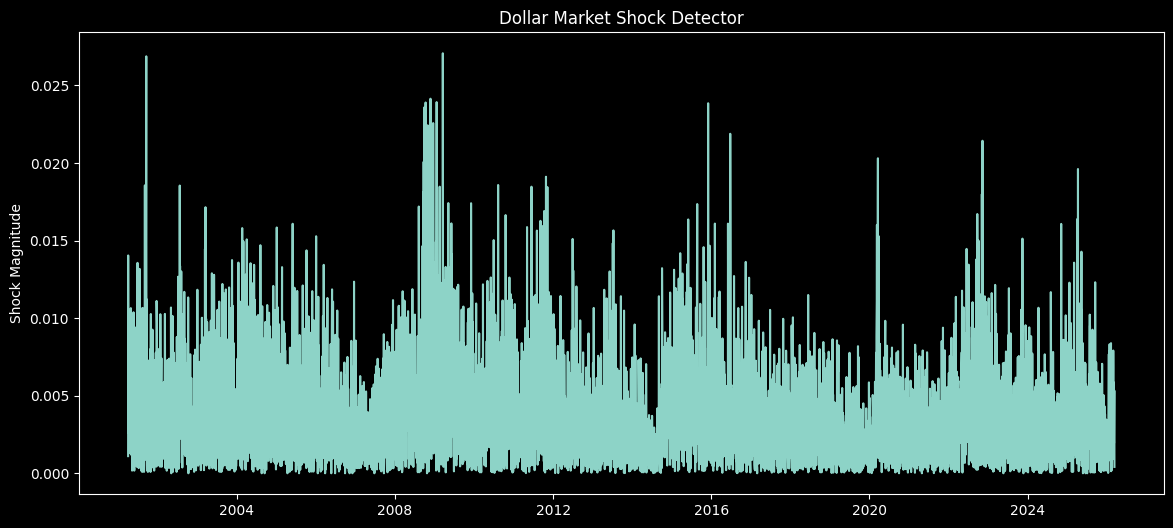

In [7]:
shock = abs(df["Return"])

plt.figure(figsize=(14,6))

plt.plot(df.index, shock)

plt.title("Dollar Market Shock Detector")

plt.ylabel("Shock Magnitude")

plt.show()

# Visualization 4
## Global Currency Risk Map

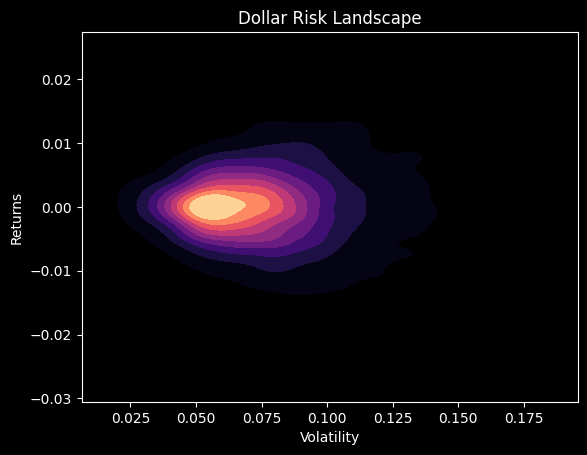

In [8]:
sns.kdeplot(
    x=df["Volatility"],
    y=df["Return"],
    cmap="magma",
    fill=True
)

plt.title("Dollar Risk Landscape")

plt.xlabel("Volatility")
plt.ylabel("Returns")

plt.show()

# Visualization 5
## Drawdown Landscape

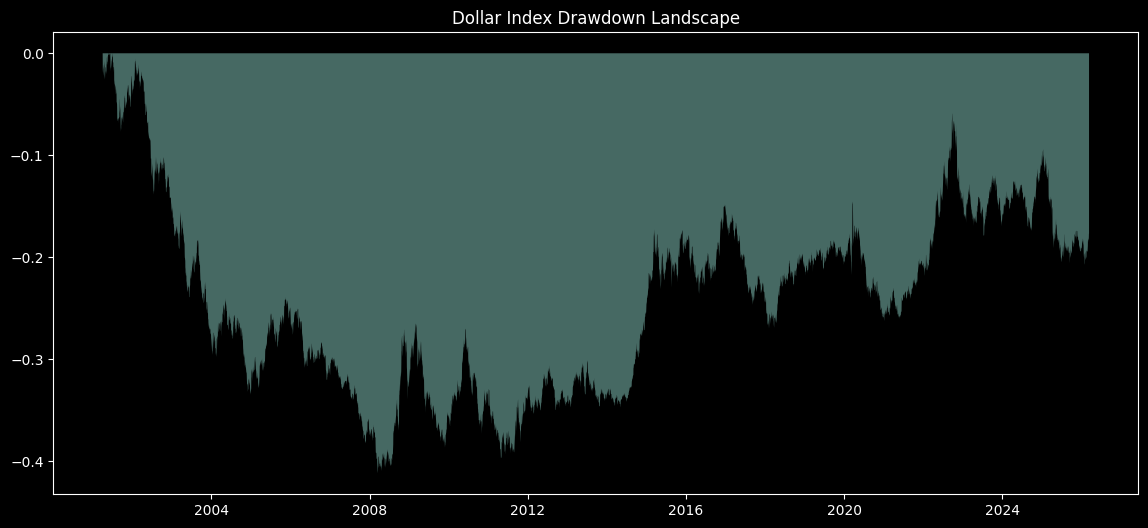

In [9]:
cum = (1 + df["Return"]).cumprod()

rolling_max = cum.cummax()

drawdown = (cum - rolling_max) / rolling_max

plt.figure(figsize=(14,6))

plt.fill_between(drawdown.index, drawdown, 0, alpha=0.5)

plt.title("Dollar Index Drawdown Landscape")

plt.show()